# Tutorial 4 — known companions and disks

Optimizing by injection-recovery assumes the field is *empty* apart from the fakes you
put in it.  A real companion — or a bright disk — breaks that assumption in three
places at once:

1. an injected companion may land **on top of** the real one, and the two blend into a
   meaningless score;
2. the real source sits in the **noise ring** used by the Mawet small-sample S/N, so σ at
   its separation is overestimated and every injection at that radius scores too low —
   the optimizer is then tuned by a biased objective;
3. the same σ goes into the **contrast curve**, which develops a bump exactly at the
   separation where you detected something.

klip-tpe takes one list, `known = [(ρ_arcsec, PA_deg), …]`, and applies it in all three
places.  This notebook shows what each one does, on β Pic — whose planet (0.45″,
PA 212°) *and* edge-on debris disk (PA ≈ 29°/209°) are both in the field.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

from klip_tpe import datasets
from klip_tpe.instruments import generic
from klip_tpe.reducer import ReductionRequest
from klip_tpe.metrics import MawetPeakSNR, Objective, Source
from klip_tpe.positions import PositionSampler
from klip_tpe.products import noise_profile, contrast_curve

files = datasets.fetch("naco_betapic")
inst = datasets.INSTRUMENT["naco_betapic"]
ds = generic.load_cube(files["cube"], files["angles"], psf=files["psf"], name="betapic")
red = generic.make_reducer({"betapic": ds}, star_flux=generic.star_flux_from_halo(ds), **inst)
space = generic.make_space(red, k_klip_max=30)
space.project = generic.make_guard(red, k_max=30)
cfg0 = space.decode(space.default_vector())
img = red.reduce(ReductionRequest(params=dict(cfg0.params, inrad=8, outrad=30, k_klip=10))).image
PX, FWHM = red.pxscale, red.fwhm
print(f"pixel scale {PX}\"/px, FWHM {FWHM:.2f} px")

  betapic: 61 frames 101x101 px, PA span 81.4 deg, injection template (flux unit 9.11e+05), fwhm 3.61 px, lambda/D 3.52 px
pixel scale 0.02719"/px, FWHM 3.61 px


## 1. Where is it?

`known` is given in the metric's convention: **ρ in arcsec, PA in degrees east of
north**, with North up and East left after derotation.  In pixels that is
`x = cx − ρ/px · sin(PA)`, `y = cy + ρ/px · cos(PA)` about the star at
`((nx−1)/2, (ny−1)/2)`.  Two helpers, and the position of the brightest source in the
default reduction:

brightest source: pixel (58, 36)  ->  rho 0.438"  PA 209.7 deg


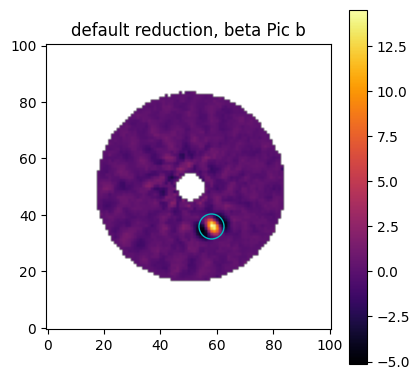

In [2]:
def to_pixels(rho_as, pa_deg, shape, pxscale):
    cx, cy = (shape[1] - 1) / 2.0, (shape[0] - 1) / 2.0
    r = rho_as / pxscale
    return cx - r * np.sin(np.deg2rad(pa_deg)), cy + r * np.cos(np.deg2rad(pa_deg))

def to_sky(x, y, shape, pxscale):
    cx, cy = (shape[1] - 1) / 2.0, (shape[0] - 1) / 2.0
    dx, dy = x - cx, y - cy
    return float(np.hypot(dx, dy) * pxscale), float(np.degrees(np.arctan2(-dx, dy)) % 360.0)

iy, ix = np.unravel_index(np.nanargmax(np.nan_to_num(img, nan=-np.inf)), img.shape)
rho_b, pa_b = to_sky(ix, iy, img.shape, PX)
print(f"brightest source: pixel ({ix}, {iy})  ->  rho {rho_b:.3f}\"  PA {pa_b:.1f} deg")
KNOWN = [(rho_b, pa_b)]                       # beta Pic b; add one entry per real source

plt.figure(figsize=(4.6, 4.6)); plt.imshow(img, origin="lower", cmap="inferno")
xb, yb = to_pixels(*KNOWN[0], img.shape, PX)
plt.plot(xb, yb, "o", mfc="none", mec="c", ms=18); plt.title("default reduction, beta Pic b"); plt.colorbar();

For a source you know from the literature, just type it in — a position good to a FWHM
is enough, since the exclusions have a radius of `excl_fwhm = 1.5` FWHM.  Refine it with
a centroid if you want, but do not fit it from a heavily self-subtracted image.

## 2. Effect on the noise and the contrast curve

`noise_profile` measures σ(r) from `⌊2πr/FWHM⌋` apertures around each ring.  β Pic b
occupies one of them:

sigma at the planet's separation: 8.53 -> 4.54 (47% lower with the planet excluded)


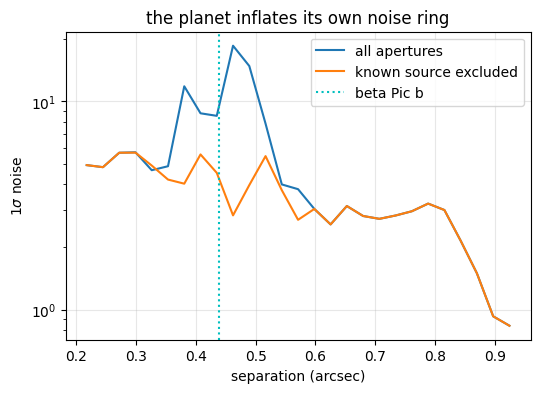

In [3]:
sig_raw, rr = noise_profile(img, FWHM, 8, 45)
sig_ex, _ = noise_profile(img, FWHM, 8, 45, known=KNOWN, pxscale=PX)
i = int(np.argmin(np.abs(rr * PX - KNOWN[0][0])))
print(f"sigma at the planet's separation: {sig_raw[i]:.3g} -> {sig_ex[i]:.3g} "
      f"({100 * (1 - sig_ex[i] / sig_raw[i]):.0f}% lower with the planet excluded)")

plt.figure(figsize=(6, 4))
plt.semilogy(rr * PX, sig_raw, label="all apertures")
plt.semilogy(rr * PX, sig_ex, label="known source excluded")
plt.axvline(KNOWN[0][0], color="c", ls=":", label="beta Pic b")
plt.xlabel("separation (arcsec)"); plt.ylabel("1$\\sigma$ noise"); plt.legend(); plt.grid(alpha=.3)
plt.title("the planet inflates its own noise ring");

The same σ drives the 5σ contrast curve, so an unmasked companion makes the limit look
*worse* exactly where you found it.  `Runner` passes the objective's `known` list to
`contrast_curve` automatically; called by hand it is the `known=` argument:

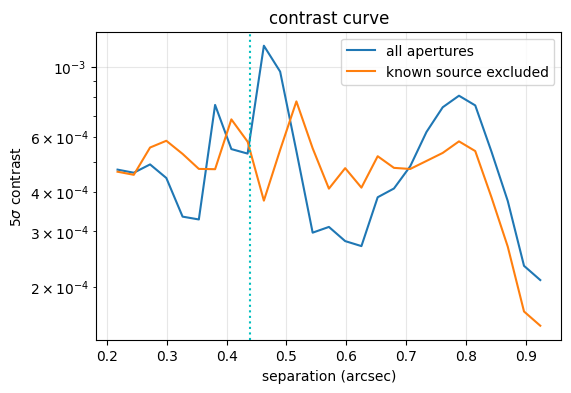

In [4]:
r_s = np.linspace(0.25, 0.75, 8)                       # pretend injection samples
s_s = np.full_like(r_s, 5.0)
cc_raw = contrast_curve(img, r_s, s_s, 5e-4, FWHM, PX, 8, 45)
cc_ex = contrast_curve(img, r_s, s_s, 5e-4, FWHM, PX, 8, 45, known=KNOWN)
plt.figure(figsize=(6, 4))
plt.semilogy(cc_raw["r_as"], cc_raw["curve"], label="all apertures")
plt.semilogy(cc_ex["r_as"], cc_ex["curve"], label="known source excluded")
plt.axvline(KNOWN[0][0], color="c", ls=":"); plt.xlabel("separation (arcsec)")
plt.ylabel("5$\\sigma$ contrast"); plt.legend(); plt.grid(alpha=.3); plt.title("contrast curve");

## 3. Effect on the injections

The position sampler refuses to place an injection within `excl_fwhm` FWHM of a known
source (and of the other injections).  Without the list, a few percent of the draws land
on the planet — those evaluations score nonsense:

In [5]:
rng = np.random.default_rng(0)
band = (0.40, 0.50)                                    # the annulus the injections go into
def hits(known, n=4000):
    s = PositionSampler(fwhm_as=FWHM * PX, known=known)
    bad = 0
    for _ in range(n // 2):
        for src in s.sample(2, band[0], band[1], rng, 5e-4):
            dx = src.rho * np.sin(np.deg2rad(src.theta)) - KNOWN[0][0] * np.sin(np.deg2rad(KNOWN[0][1]))
            dy = src.rho * np.cos(np.deg2rad(src.theta)) - KNOWN[0][0] * np.cos(np.deg2rad(KNOWN[0][1]))
            bad += np.hypot(dx, dy) < 1.5 * FWHM * PX
    return 100.0 * bad / n
print(f"injections landing on beta Pic b: {hits([]):.1f}% without known=, {hits(KNOWN):.1f}% with it")

injections landing on beta Pic b: 10.4% without known=, 0.0% with it


And the metric leaves the known source out of the noise apertures when it scores an
injection, so the score no longer depends on how far the injection happens to be from
the planet:

In [6]:
m_raw = MawetPeakSNR(pxscale=PX, fwhm=FWHM, kernel_fn=red.matched_filter_kernel)
m_ex = MawetPeakSNR(pxscale=PX, fwhm=FWHM, kernel_fn=red.matched_filter_kernel, known=KNOWN)
inj = red.reduce(ReductionRequest(params=dict(cfg0.params, inrad=8, outrad=30, k_klip=10),
                                  injections=[Source(KNOWN[0][0], (KNOWN[0][1] + 90) % 360, 2e-3)])).image
pa_inj = (KNOWN[0][1] + 90) % 360
print(f"injection at rho {KNOWN[0][0]:.2f}\", PA {pa_inj:.0f} deg:")
print(f"  S/N with the planet in the noise ring : {m_raw.per_source(inj, None, [KNOWN[0][0]], [pa_inj])[0]:.2f}")
print(f"  S/N with the planet excluded          : {m_ex.per_source(inj, None, [KNOWN[0][0]], [pa_inj])[0]:.2f}")

injection at rho 0.44", PA 300 deg:
  S/N with the planet in the noise ring : 2.85
  S/N with the planet excluded          : 8.58


## 4. Declaring it once, for a whole run

`default_config(..., known=[...])` builds both the metric and the sampler with the list,
and `Runner` forwards it to the contrast curve — so one argument covers all three uses:

```python
objective, sampler = generic.default_config(red, known=[(0.452, 211.9)])
Runner(red, space, objective, sampler, cfg, run_dir).run()
```

The same list goes on the command line as `--known rho pa` (repeatable):

```
klip-tpe generic --cube ... --angles ... --known 0.452 211.9 --known 1.13 40.0 ...
```

In [7]:
objective, sampler = generic.default_config(red, known=KNOWN)
print("metric knows :", objective.metric.known)
print("sampler knows:", sampler.known, f"(exclusion radius {sampler.excl_fwhm} FWHM)")

metric knows : [(0.4384255763524751, 209.7448812969422)]
sampler knows: [(0.4384255763524751, 209.7448812969422)] (exclusion radius 1.5 FWHM)


## 5. Disks and other extended signal

A point-source exclusion list does not describe a disk.  Two further knobs:

* `PositionSampler(forbidden_pa=[(centre_deg, half_width_deg), …])` keeps injections out
  of whole position-angle sectors — the natural way to avoid an edge-on disk (β Pic's
  lies along PA ≈ 29°/209°) or a diffraction feature.
* `MawetPeakSNR(pixel_mask=mask)` takes a boolean image (`True` = ignore) that is removed
  from the noise apertures — for a disk, a spider, a bad-pixel region.

Both accept the same geometry as everything else: North up, PA east of north.

injected PAs inside the disk wedge: 0.0%


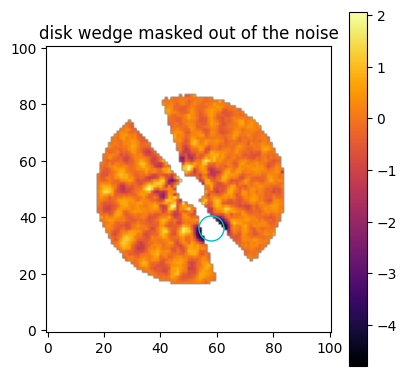

In [8]:
yy, xx = np.mgrid[0:img.shape[0], 0:img.shape[1]]
cx, cy = (img.shape[1] - 1) / 2.0, (img.shape[0] - 1) / 2.0
pa_pix = np.degrees(np.arctan2(-(xx - cx), yy - cy)) % 360.0
disk = np.minimum(np.abs(pa_pix - 29.0), np.abs(pa_pix - 209.0))          # distance to the disk axis
disk_mask = np.minimum(disk, 360.0 - disk) < 12.0                        # +-12 deg wedge
m_disk = MawetPeakSNR(pxscale=PX, fwhm=FWHM, kernel_fn=red.matched_filter_kernel,
                      known=KNOWN, pixel_mask=disk_mask)
sampler_disk = PositionSampler(fwhm_as=FWHM * PX, known=KNOWN, forbidden_pa=[(29.0, 15.0), (209.0, 15.0)])
pos = [sampler_disk.sample(2, 0.4, 0.5, rng, 5e-4) for _ in range(200)]
pas = np.array([s.theta for p in pos for s in p])
print(f"injected PAs inside the disk wedge: {100 * np.mean(np.minimum(np.abs(pas - 29) % 360, np.abs(pas - 209) % 360) < 15):.1f}%")

plt.figure(figsize=(4.6, 4.6)); plt.imshow(np.where(disk_mask, np.nan, img), origin="lower", cmap="inferno")
plt.plot(xb, yb, "o", mfc="none", mec="c", ms=18)
plt.title("disk wedge masked out of the noise"); plt.colorbar();

## 6. When the known source is the point of the run

Excluding a companion keeps it from biasing the optimization.  If instead you want the
reduction *tuned for it* — the best possible image of a companion you already know —
match the injections to it:

* put the annulus around its separation, so the injections land where it is
  (`ann_edges` such that √((r_in² + r_out²)/2) ≈ ρ);
* force the injection contrast to its own instead of calibrating to S/N ≈ 5:
  `CalibrationConfig(forced=[c])`, with `c` estimated from its known Δmag;
* keep it in `known` all the same, so no injection lands on it.

The optimum depends on the contrast you optimize for: parameters that maximise the S/N of
a companion at the detection limit are not the ones that maximise a bright companion's.
Tutorial 1 shows both numbers for β Pic b.